In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split


In [2]:
iris = load_iris()

X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df["species"] = y


In [3]:
print(df.head())
print(df.info())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes:

In [9]:
target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

<Figure size 800x600 with 0 Axes>

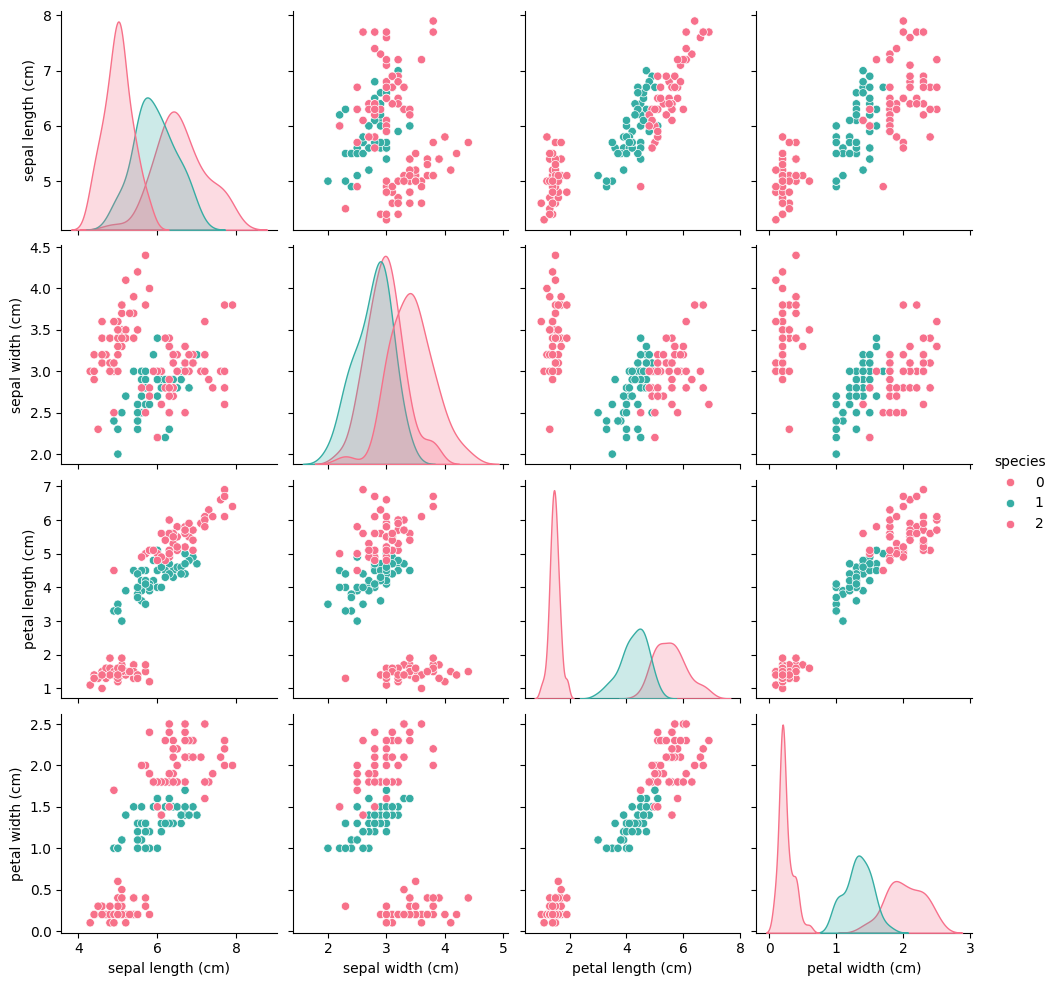

In [40]:
plt.figure(figsize=(8,6))
sns.pairplot(df, hue="species", palette="husl")
plt.show()


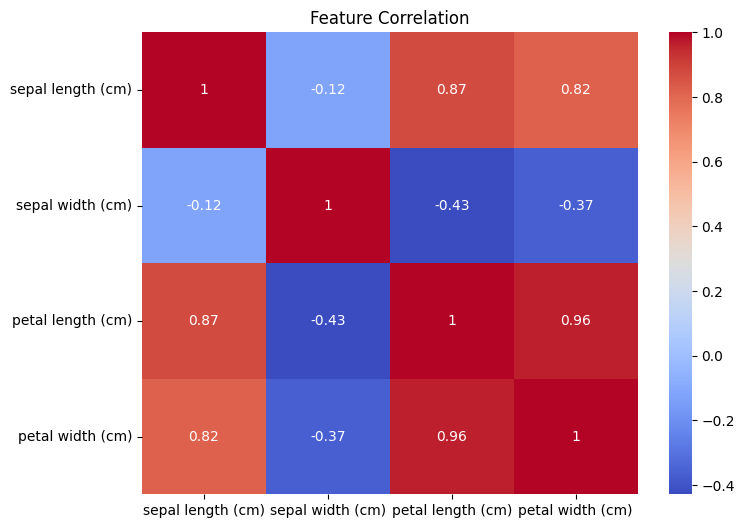

In [42]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop("species", axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()


In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [45]:
X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).long()

X_test_tensor = torch.from_numpy(X_test).float()
y_test_tensor = torch.from_numpy(y_test).long()

In [47]:
X_train_tensor.shape, y_train_tensor.shape

(torch.Size([120, 4]), torch.Size([120]))

In [48]:
class CustomData(torch.utils.data.Dataset):
  def __init__(self, X, y):
    self.X = X
    self.y = y
  def __len__(self):
    return len(self.X)
  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [49]:
train_dataset = CustomData(X_train_tensor, y_train_tensor)
test_dataset = CustomData(X_test_tensor, y_test_tensor)

In [50]:
train_loader = DataLoader(train_dataset, batch_size=30, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=30, shuffle=False)

In [52]:
class myANN(nn.Module):
  def __init__(self, input):
    super(myANN, self).__init__()
    self.layers = nn.Sequential(
        nn.Linear(input, 12), nn.ReLU(),
        nn.Linear(12, 9), nn.ReLU(),
        nn.Linear(9, 3)
    )

  def forward(self, x):
    return self.layers(x);


In [76]:
model = myANN(X_train.shape[1])

In [55]:
model

myANN(
  (layers): Sequential(
    (0): Linear(in_features=4, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=9, bias=True)
    (3): ReLU()
    (4): Linear(in_features=9, out_features=3, bias=True)
  )
)

In [77]:
# Training pipeline:
epochs = 25
lr = 0.01

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

model.train()
loss_hist = []

for i in range(epochs):
    epoch_loss = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        y_pred = model(data)
        loss = criterion(y_pred, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    loss_hist.append(epoch_loss)

    print(f"Epochs: {i + 1} / {epochs} - loss: {epoch_loss}")

Epochs: 1 / 25 - loss: 1.2382486164569855
Epochs: 2 / 25 - loss: 1.0452502965927124
Epochs: 3 / 25 - loss: 0.9582272171974182
Epochs: 4 / 25 - loss: 0.8738273680210114
Epochs: 5 / 25 - loss: 0.7643831968307495
Epochs: 6 / 25 - loss: 0.6472604125738144
Epochs: 7 / 25 - loss: 0.5567937195301056
Epochs: 8 / 25 - loss: 0.47035300731658936
Epochs: 9 / 25 - loss: 0.40135572105646133
Epochs: 10 / 25 - loss: 0.3579486086964607
Epochs: 11 / 25 - loss: 0.31044652312994003
Epochs: 12 / 25 - loss: 0.29117855802178383
Epochs: 13 / 25 - loss: 0.2565112002193928
Epochs: 14 / 25 - loss: 0.2350514605641365
Epochs: 15 / 25 - loss: 0.1952349729835987
Epochs: 16 / 25 - loss: 0.18221687525510788
Epochs: 17 / 25 - loss: 0.17191315814852715
Epochs: 18 / 25 - loss: 0.1424929853528738
Epochs: 19 / 25 - loss: 0.1387519259005785
Epochs: 20 / 25 - loss: 0.13192031905055046
Epochs: 21 / 25 - loss: 0.11781107448041439
Epochs: 22 / 25 - loss: 0.10847865231335163
Epochs: 23 / 25 - loss: 0.09971063304692507
Epochs: 24

In [81]:
model.eval()

test_loss = 0
correct = 0

with torch.no_grad():
    for batch_idx, (data, target) in enumerate(test_loader):
        y_pred = model(data)

        l = criterion(y_pred, target)
        test_loss += l.item()

        preds = y_pred.argmax(dim=1)
        correct += (preds == target).sum().item()

test_loss /= len(test_loader)
accuracy = correct / len(test_loader.dataset)

print(f"Test Loss: {test_loss} - Accuracy: {accuracy}")

Test Loss: 0.08969291299581528 - Accuracy: 1.0


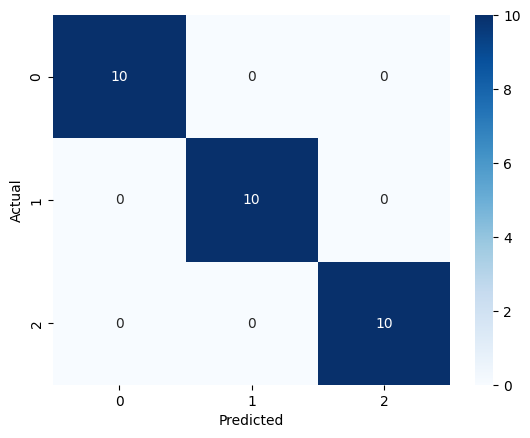

In [82]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_02 = model(X_test_tensor).argmax(dim=1)
cm = confusion_matrix(y_test_tensor, y_pred_02)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [83]:
from sklearn.metrics import classification_report

print(classification_report(y_test_tensor, y_pred_02))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



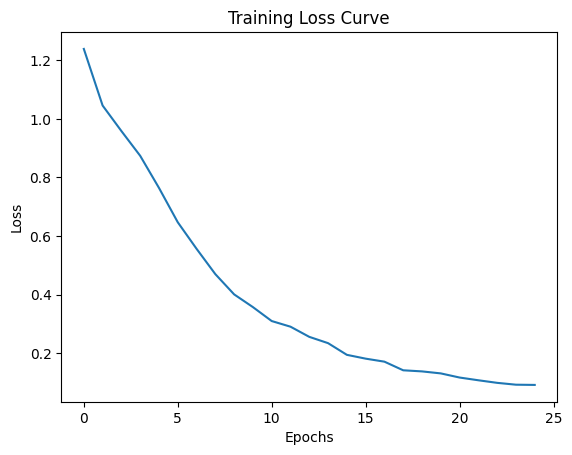

In [80]:
plt.plot(loss_hist)
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()